# Analisis de Datos Exploratorio 
En este notebook vamos a dar un primer hallazgo para poder saber con que datos estamos trabajando, saber si hay datos nulos o no normalizados. Y mas que nada poder entender con que nos estamos enfrentando con este proyeto.

El objetivo de este proyecto es poder identificar fraudes bancarios, cuales son los mas comunies y lo mas importante como prevenirlos, se va a estar trabajando con el siguiente base de datos.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('../data/01_raw/PS_20174392719_1491204439457_log.csv')

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


Tiene **6362620 filas** y **11 columnas**, el dataset se extrajo de https://www.kaggle.com/datasets/rohit265/fraud-detection-dynamics-financial-transaction el dia 01/06/2026

In [5]:
data.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `step` | Numérico | Unidad de tiempo en el mundo real (1 step = 1 hora). |
| `type` | Categórico | Tipo de transacción (CASH-IN, CASH-OUT, DEBIT, PAYMENT, TRANSFER). |
| `amount` | Numérico | El monto de la transacción (Aquí es donde debes aplicar Feature Engineering / Escalamiento). |
| `oldbalanceOrg` | Numérico | Balance inicial de la cuenta de origen antes de la transacción. |
| `newbalanceOrig` | Numérico | Balance nuevo de la cuenta de origen después de la transacción. |
| `oldbalanceDest` | Numérico | Balance inicial del destinatario antes de la transacción. |
| `newbalanceDest` | Numérico | Balance nuevo del destinatario después de la transacción. |
| `isFraud` | Binario (0 o 1) | Tu variable objetivo (Target). Indica si la transacción fue un fraude real. |

Hay que normalizar los datos pata que todas las columnas sean en minusculas, verificar que no haya datos numericos y que en los datos numericos solo haya puros datos numericos.

## Estadistica Descriptiva

In [30]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [31]:
data.isna().sum().sort_values(ascending=False)

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Como se ve, es una base de datos bonita ya que no tenemos datos nulos, muchos de los datos son de tipo float o string por lo que solo hay que reforzar que los datos esten normalizados.

In [32]:
total_duplicados = data.duplicated().sum()
print(f"Total de transacciones duplicadas: {total_duplicados}")

Total de transacciones duplicadas: 0


## Deteccion de valores atipicos

In [10]:
cuartiles = data['amount'].quantile([0.25, 0.5, 0.75]) 

rango = data['amount'].max() - data['amount'].min()

print(cuartiles)

0.25     13389.5700
0.50     74871.9400
0.75    208721.4775
Name: amount, dtype: float64


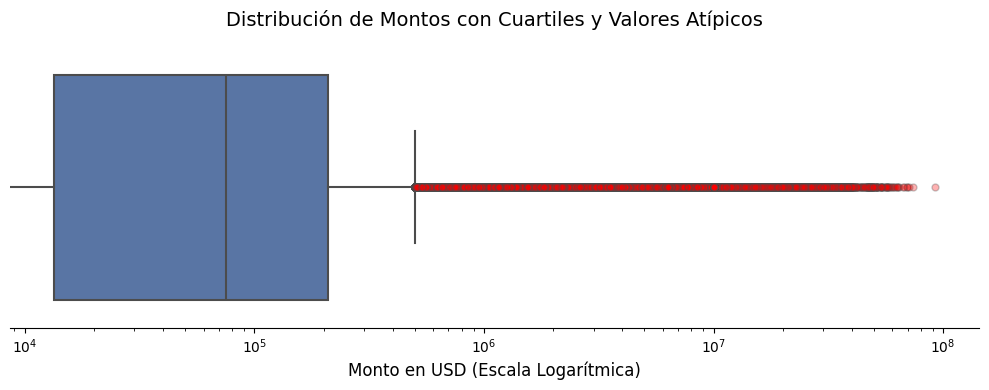

In [11]:
plt.figure(figsize=(10, 4))


sns.boxplot(
    x=data['amount'], 
    color='#4C72B0', 
    linewidth=1.5,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'alpha': 0.3} # Estiliza los valores atípicos
)


plt.xscale('log')


plt.title('Distribución de Montos con Cuartiles y Valores Atípicos', fontsize=14, pad=15)
plt.xlabel('Monto en USD (Escala Logarítmica)', fontsize=12)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().get_yaxis().set_visible(False) 

plt.tight_layout()
plt.show()

In [13]:
cuartiles = data['oldbalanceOrg'].quantile([0.25, 0.5, 0.75]) 
rango = data['oldbalanceOrg'].max() - data['oldbalanceOrg'].min()
print(cuartiles)

0.25         0.000
0.50     14208.000
0.75    107315.175
Name: oldbalanceOrg, dtype: float64


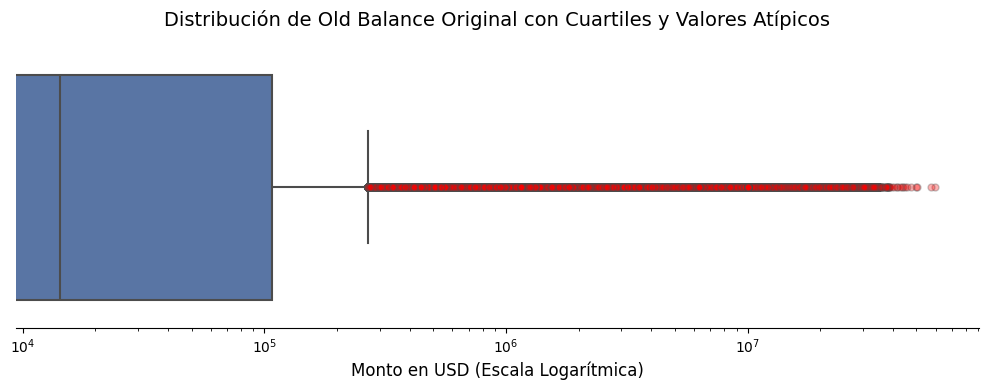

In [24]:
plt.figure(figsize=(10, 4))


sns.boxplot(
    x=data['oldbalanceOrg'], 
    color='#4C72B0', 
    linewidth=1.5,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'alpha': 0.3} # Estiliza los valores atípicos
)


plt.xscale('log')


plt.title('Distribución de Old Balance Original con Cuartiles y Valores Atípicos', fontsize=14, pad=15)
plt.xlabel('Monto en USD (Escala Logarítmica)', fontsize=12)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().get_yaxis().set_visible(False) 

plt.tight_layout()
plt.show()

In [16]:
cuartiles = data['newbalanceOrig'].quantile([0.25, 0.5, 0.75]) 
rango = data['newbalanceOrig'].max() - data['newbalanceOrig'].min()
print(cuartiles)

0.25         0.00
0.50         0.00
0.75    144258.41
Name: newbalanceOrig, dtype: float64


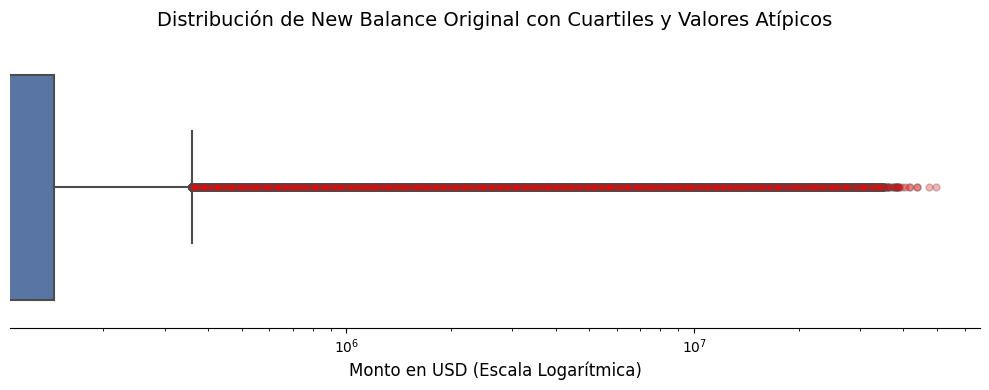

In [25]:
plt.figure(figsize=(10, 4))


sns.boxplot(
    x=data['newbalanceOrig'], 
    color='#4C72B0', 
    linewidth=1.5,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'alpha': 0.3} # Estiliza los valores atípicos
)


plt.xscale('log')


plt.title('Distribución de New Balance Original con Cuartiles y Valores Atípicos', fontsize=14, pad=15)
plt.xlabel('Monto en USD (Escala Logarítmica)', fontsize=12)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().get_yaxis().set_visible(False) 

plt.tight_layout()
plt.show()

In [19]:
cuartiles = data['oldbalanceDest'].quantile([0.25, 0.5, 0.75]) 
rango = data['oldbalanceDest'].max() - data['oldbalanceDest'].min()
print(cuartiles)

0.25         0.0000
0.50    132705.6650
0.75    943036.7075
Name: oldbalanceDest, dtype: float64


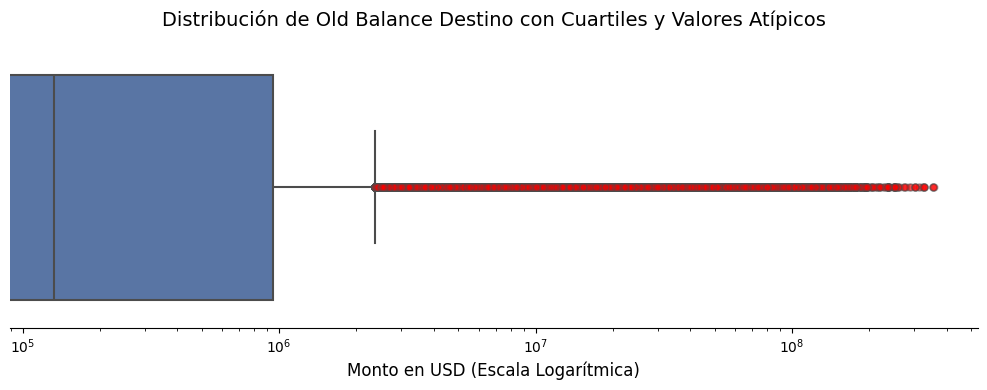

In [27]:
plt.figure(figsize=(10, 4))


sns.boxplot(
    x=data['oldbalanceDest'], 
    color='#4C72B0', 
    linewidth=1.5,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'alpha': 0.3} # Estiliza los valores atípicos
)


plt.xscale('log')


plt.title('Distribución de Old Balance Destino con Cuartiles y Valores Atípicos', fontsize=14, pad=15)
plt.xlabel('Monto en USD (Escala Logarítmica)', fontsize=12)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().get_yaxis().set_visible(False) 

plt.tight_layout()
plt.show()

In [21]:
cuartiles = data['newbalanceDest'].quantile([0.25, 0.5, 0.75]) 
rango = data['newbalanceDest'].max() - data['newbalanceDest'].min()
print(cuartiles)

0.25          0.00
0.50     214661.44
0.75    1111909.25
Name: newbalanceDest, dtype: float64


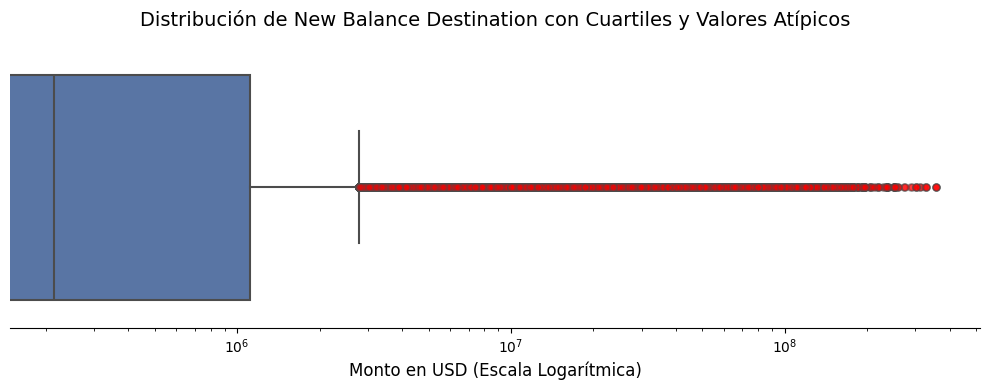

In [29]:
plt.figure(figsize=(10, 4))


sns.boxplot(
    x=data['newbalanceDest'], 
    color='#4C72B0', 
    linewidth=1.5,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'alpha': 0.3} # Estiliza los valores atípicos
)


plt.xscale('log')


plt.title('Distribución de New Balance Destination con Cuartiles y Valores Atípicos', fontsize=14, pad=15)
plt.xlabel('Monto en USD (Escala Logarítmica)', fontsize=12)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().get_yaxis().set_visible(False) 

plt.tight_layout()
plt.show()

## Distribuciones

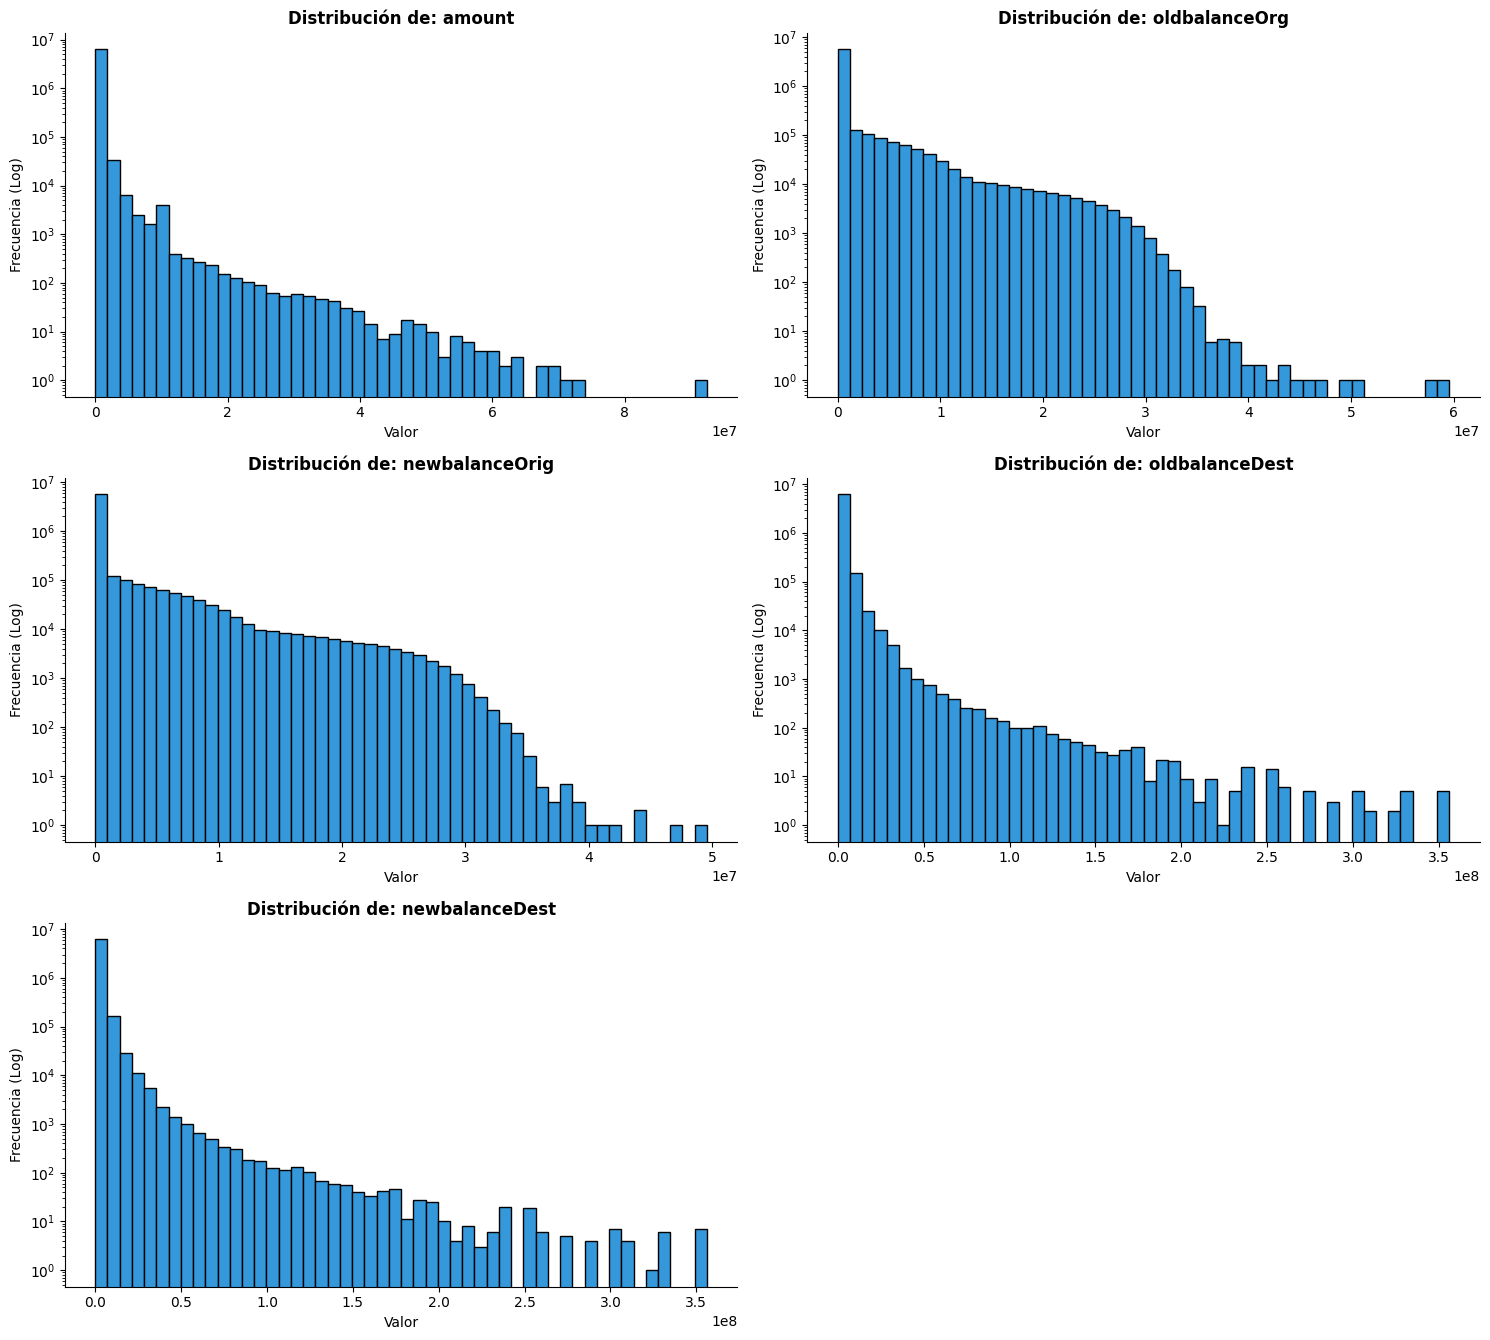

In [ ]:
import math

columnas_excluir = ['isFraud', 'isFlaggedFraud', 'step'] 
columnas_numericas = data.select_dtypes(include=['number']).columns.tolist()
vars_relevantes = [col for col in columnas_numericas if col not in columnas_excluir]

filas = math.ceil(len(vars_relevantes) / 2)
fig, axes = plt.subplots(filas, 2, figsize=(15, filas * 4.5))
axes = axes.flatten() 


for i, columna in enumerate(vars_relevantes):
    axes[i].hist(data[columna].dropna(), bins=50, color='#3498db', edgecolor='black')
    
    axes[i].set_yscale('log')
    
    axes[i].set_title(f'Distribución de: {columna}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=10)
    axes[i].set_ylabel('Frecuencia (Log)', fontsize=10)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Relaciones entre Variables

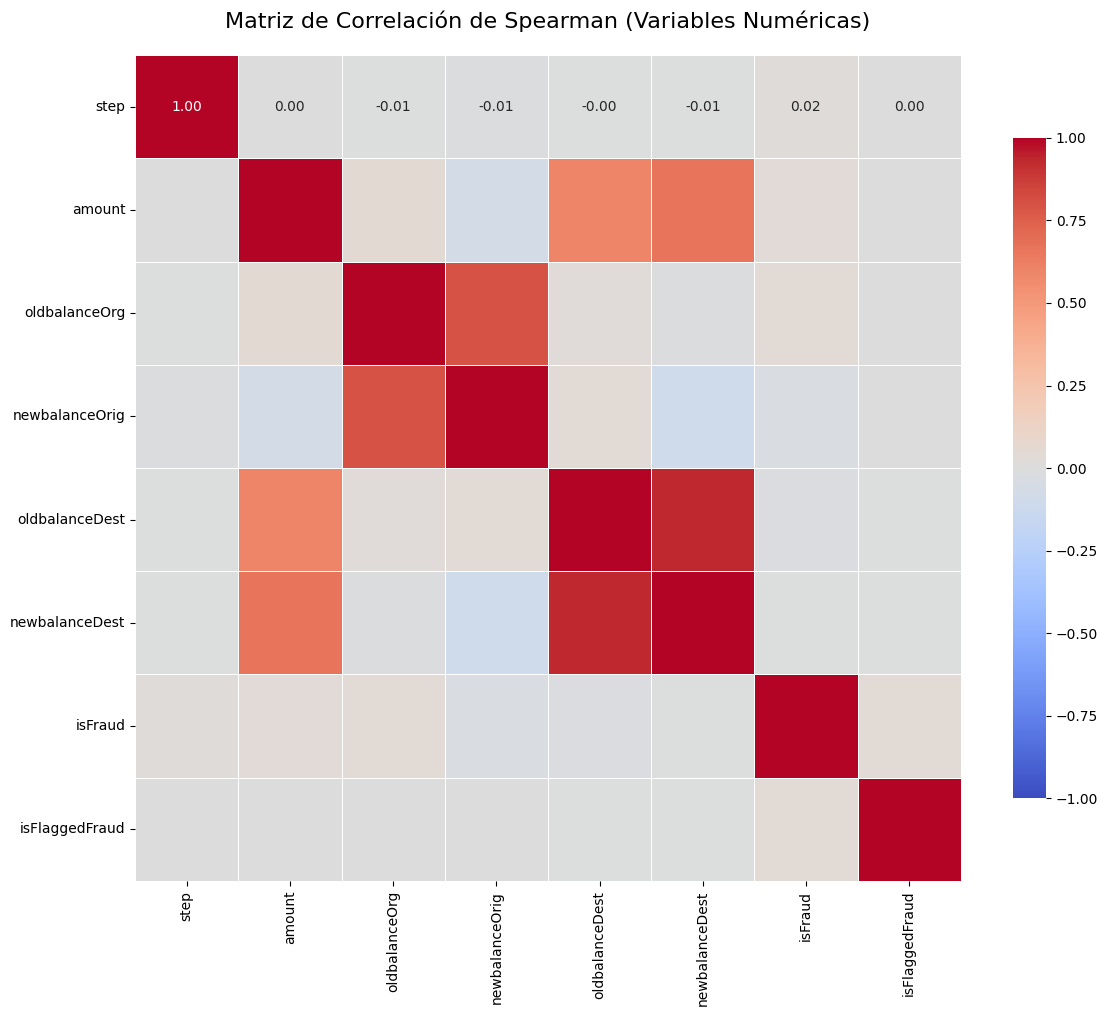

In [33]:

df_numerico = data.select_dtypes(include=['number'])

matriz_corr = df_numerico.corr(method='spearman')


plt.figure(figsize=(12, 10))


sns.heatmap(
    matriz_corr, 
    annot=True,        
    fmt=".2f",        
    cmap="coolwarm",   
    vmin=-1, vmax=1, 
    square=True,     
    linewidths=0.5,    
    cbar_kws={"shrink": .8} 
)

plt.title('Matriz de Correlación de Spearman (Variables Numéricas)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## Análisis de variables categóricas

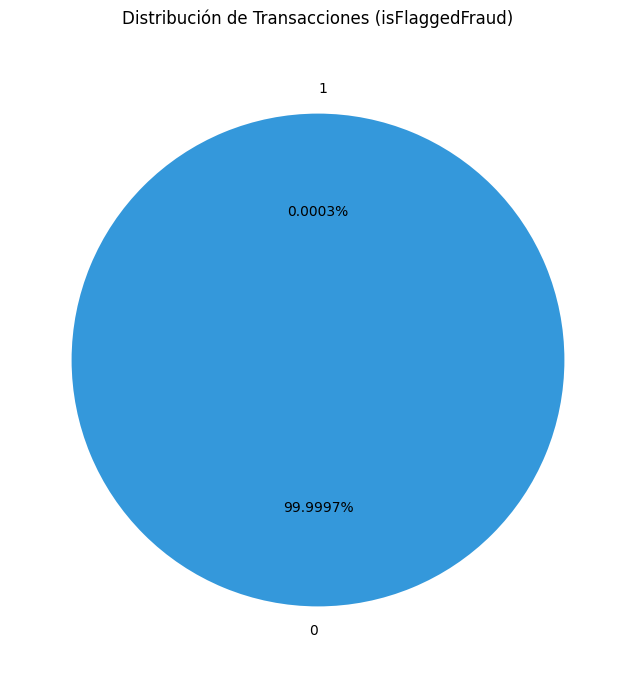

In [26]:
# Obtener los conteos
conteo_isflagged = data['isFlaggedFraud'].value_counts()

# Crear la gráfica de pastel
conteo_isflagged.plot(
    kind='pie', 
    figsize=(8, 8), 
    colors=['#3498db', '#e74c3c'], # Azul para normal, rojo para marcado
    autopct='%1.4f%%',             # Muestra el porcentaje con 4 decimales
    startangle=90                  # Gira el gráfico para mejor estética
)

plt.title('Distribución de Transacciones (isFlaggedFraud)', pad=20)
plt.ylabel('')  # Ocultamos el ylabel porque en gráficas de pastel genera ruido visual

# Mostrar el gráfico
plt.show()

Tenemos un desbalanceo en nuestra base de datos, ya que tenemos que el 0.0003 son fraudes, esto es como la mayoria de veces pasa en casos de la vida real, por que debemos de tener una buena deteccion sobre esto, esta columna es conforme a lo que el negocio establece.

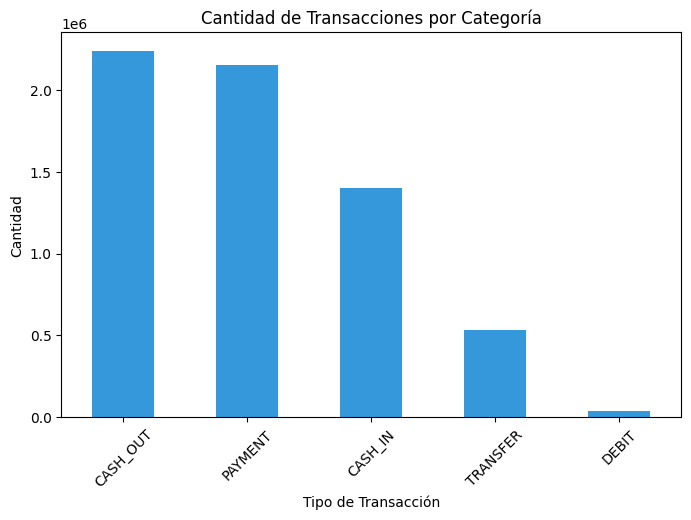

In [27]:
conteo_categorias = data['type'].value_counts()

conteo_categorias.plot(kind='bar', color='#3498db', figsize=(8, 5))

plt.title('Cantidad de Transacciones por Categoría')
plt.xlabel('Tipo de Transacción')
plt.ylabel('Cantidad')
plt.xticks(rotation=45) 
plt.show()

La mayor parte de las transacciones son de tupo de cast out seguido por el pago de cuentas y como tercer lugar se tiene las operaciones de cash in

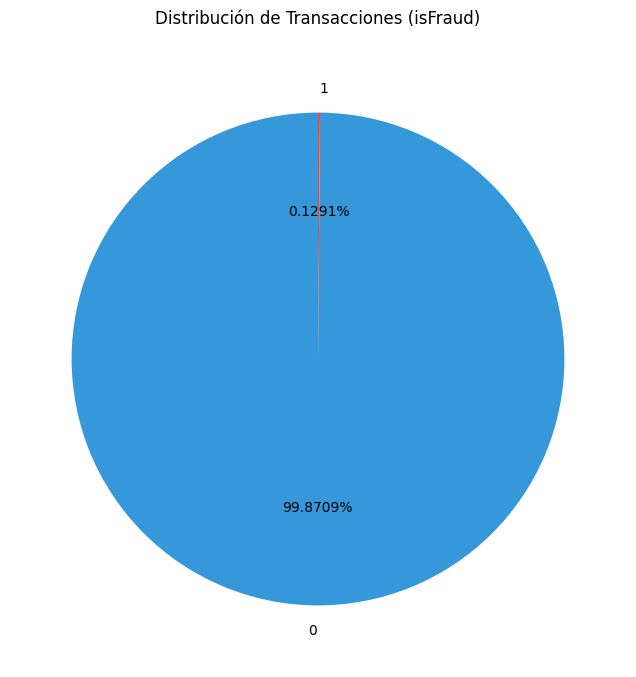

In [28]:
# Obtener los conteos
conteo_isfraud = data['isFraud'].value_counts()

# Crear la gráfica de pastel
conteo_isfraud.plot(
    kind='pie', 
    figsize=(8, 8), 
    colors=['#3498db', '#e74c3c'], # Azul para normal, rojo para marcado
    autopct='%1.4f%%',             # Muestra el porcentaje con 4 decimales
    startangle=90                  # Gira el gráfico para mejor estética
)

plt.title('Distribución de Transacciones (isFraud)', pad=20)
plt.ylabel('')  # Ocultamos el ylabel porque en gráficas de pastel genera ruido visual

# Mostrar el gráfico
plt.show()

Como pasa en el anterior caso tenemos una base de datos desbalanceado donde el 0.12% son fraudes, por lo que tenemos una base de datos que simula como es la deteccion de anomalias y el caso de ellas en la vida real

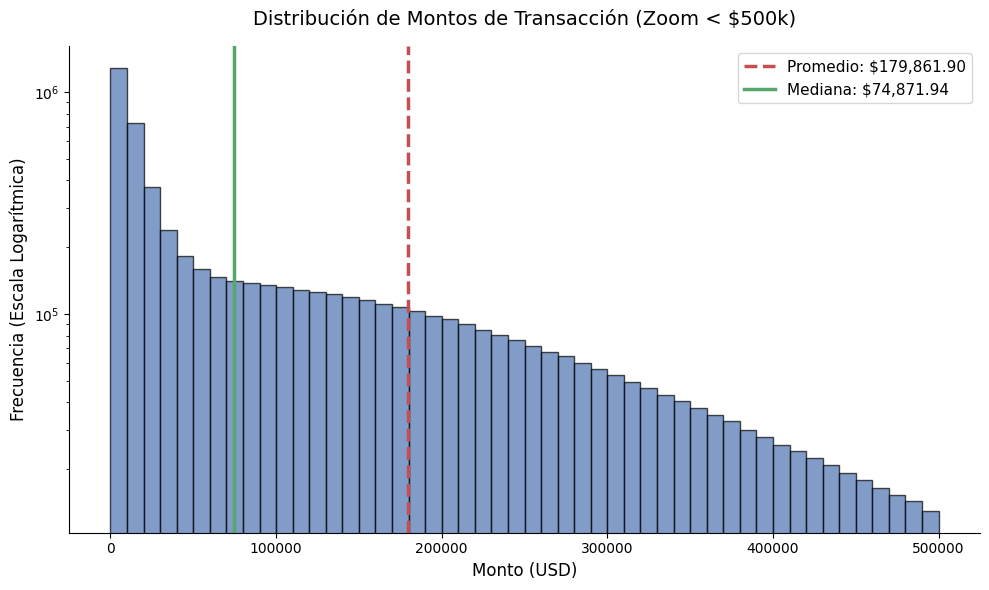

In [29]:
promedio = data['amount'].mean()
mediana = data['amount'].median()

plt.figure(figsize=(10, 6))
    

limite_visual = 500000 
plt.hist(data['amount'], bins=50, range=(0, limite_visual), 
         color='#4C72B0', edgecolor='black', alpha=0.7)

plt.axvline(promedio, color='#C44E52', linestyle='dashed', linewidth=2.5, 
            label=f'Promedio: ${promedio:,.2f}')
plt.axvline(mediana, color='#55A868', linestyle='solid', linewidth=2.5, 
            label=f'Mediana: ${mediana:,.2f}')


plt.yscale('log')


plt.title('Distribución de Montos de Transacción (Zoom < $500k)', fontsize=14, pad=15)
plt.xlabel('Monto (USD)', fontsize=12)
plt.ylabel('Frecuencia (Escala Logarítmica)', fontsize=12)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Mostrar leyenda y ajustar diseño
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

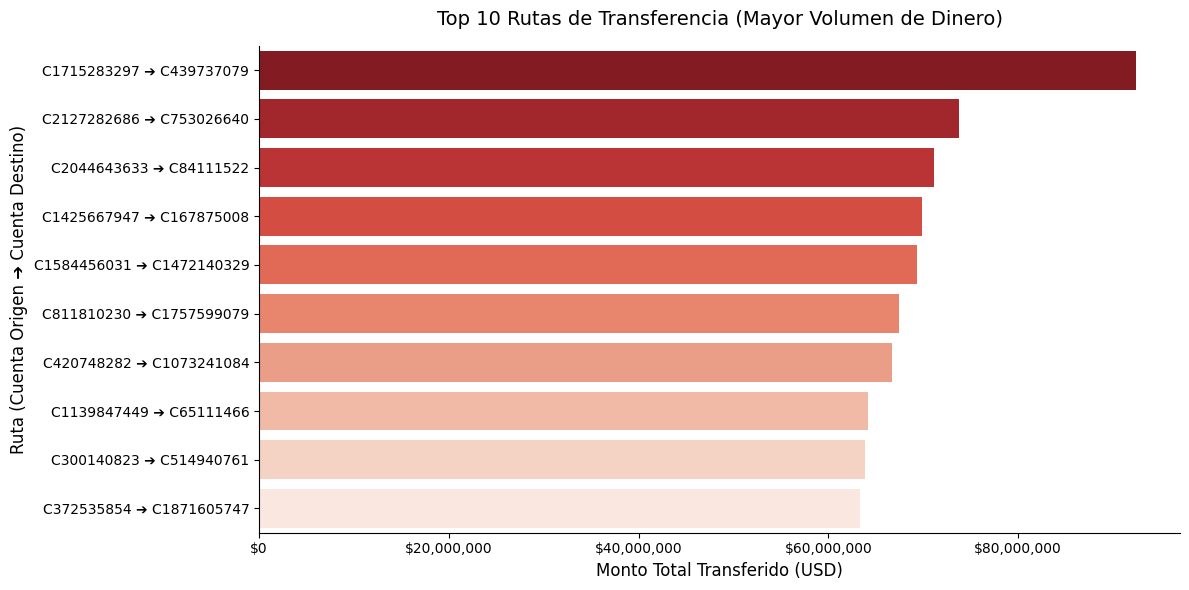

In [36]:
# 1. Crear una nueva columna que defina la "Ruta"
# Ejemplo: "C1234 ➔ C9876"
data['ruta_transferencia'] = data['nameOrig'].astype(str) + " ➔ " + data['nameDest'].astype(str)

# 2. Agrupar por ruta, sumar los montos y sacar el Top 10
top_rutas = data.groupby('ruta_transferencia')['amount'].sum().nlargest(10).reset_index()

# 3. Configurar el lienzo
plt.figure(figsize=(12, 6))

# 4. Crear la gráfica de barras horizontales
# Usamos seaborn porque maneja automáticamente los colores y el mapeo categórico
sns.barplot(
    x='amount', 
    y='ruta_transferencia', 
    data=top_rutas, 
    palette='Reds_r' # Una paleta roja descendente (alerta/riesgo)
)

# 5. Estilizar la gráfica para el reporte de auditoría
plt.title('Top 10 Rutas de Transferencia (Mayor Volumen de Dinero)', fontsize=14, pad=15)
plt.xlabel('Monto Total Transferido (USD)', fontsize=12)
plt.ylabel('Ruta (Cuenta Origen ➔ Cuenta Destino)', fontsize=12)

# Darle formato de moneda al eje X
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# Quitar bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

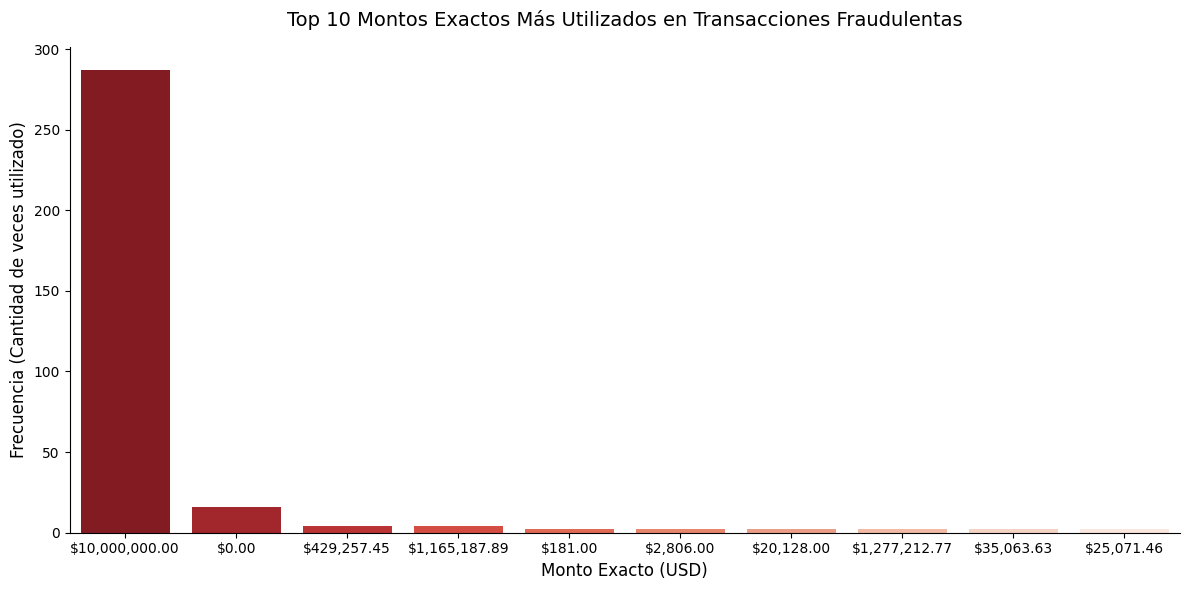

In [37]:
df_solo_fraudes = data[data['isFraud'] == 1]

# 2. Contar cuáles son los montos EXACTOS que más se repiten y sacar el Top 10
montos_comunes = df_solo_fraudes['amount'].value_counts().head(10).reset_index()
montos_comunes.columns = ['monto_exacto', 'cantidad_de_fraudes']

# 3. Configurar el lienzo
plt.figure(figsize=(12, 6))

# 4. Crear la gráfica de barras
# Convertimos los montos a texto (string) en el eje X para que Matplotlib 
# los trate como categorías discretas y no intente ordenarlos matemáticamente.
sns.barplot(
    x=montos_comunes['monto_exacto'].astype(str), 
    y=montos_comunes['cantidad_de_fraudes'], 
    palette='Reds_r' # Rojo intenso para resaltar el riesgo
)

# 5. Estilizar la gráfica
plt.title('Top 10 Montos Exactos Más Utilizados en Transacciones Fraudulentas', fontsize=14, pad=15)
plt.xlabel('Monto Exacto (USD)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de veces utilizado)', fontsize=12)

# Añadir el símbolo de dólar a las etiquetas del eje X
ax = plt.gca()
ax.set_xticklabels([f"${float(x.get_text()):,.2f}" for x in ax.get_xticklabels()])

# Quitar bordes para el estilo de auditoría
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

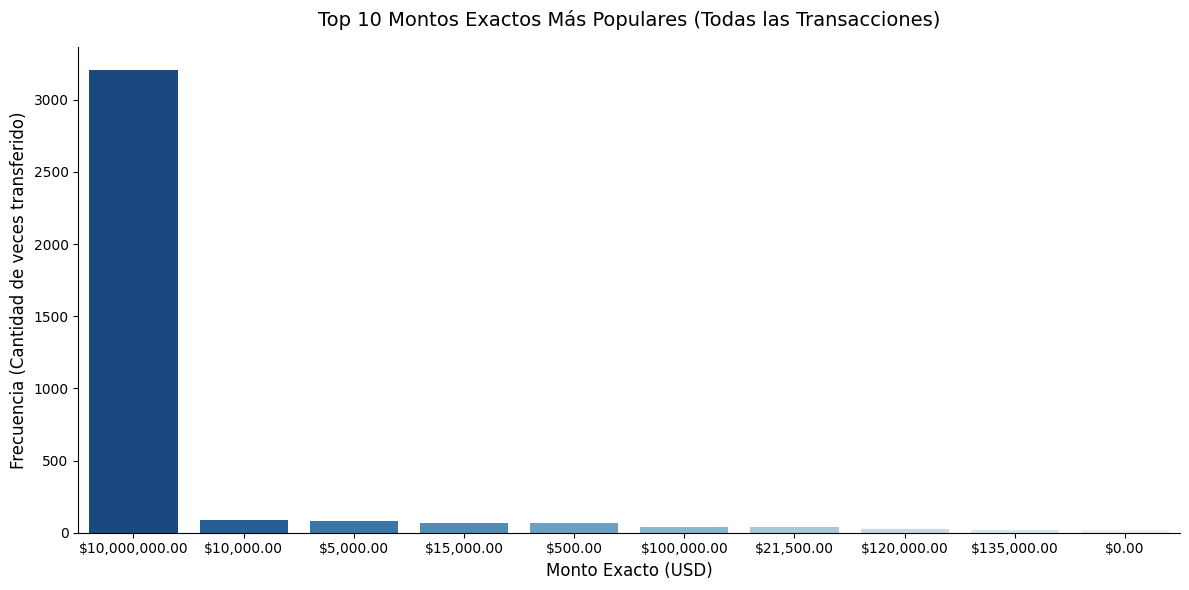

In [38]:

montos_comunes = data['amount'].value_counts().head(10).reset_index()

# Corregimos el nombre de la columna para que tenga sentido (ya no son fraudes)
montos_comunes.columns = ['monto_exacto', 'frecuencia']

# 2. Configurar el lienzo
plt.figure(figsize=(12, 6))

# 3. Crear la gráfica de barras
# Convertimos los montos a texto (string) en el eje X
sns.barplot(
    x=montos_comunes['monto_exacto'].astype(str), 
    y=montos_comunes['frecuencia'], 
    palette='Blues_r' # Azul para comportamiento general (reservamos el rojo para fraudes)
)

# 4. Estilizar la gráfica
plt.title('Top 10 Montos Exactos Más Populares (Todas las Transacciones)', fontsize=14, pad=15)
plt.xlabel('Monto Exacto (USD)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de veces transferido)', fontsize=12)

# Añadir el símbolo de dólar a las etiquetas del eje X
ax = plt.gca()
ax.set_xticklabels([f"${float(x.get_text()):,.2f}" for x in ax.get_xticklabels()])

# Quitar bordes para el estilo de auditoría
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

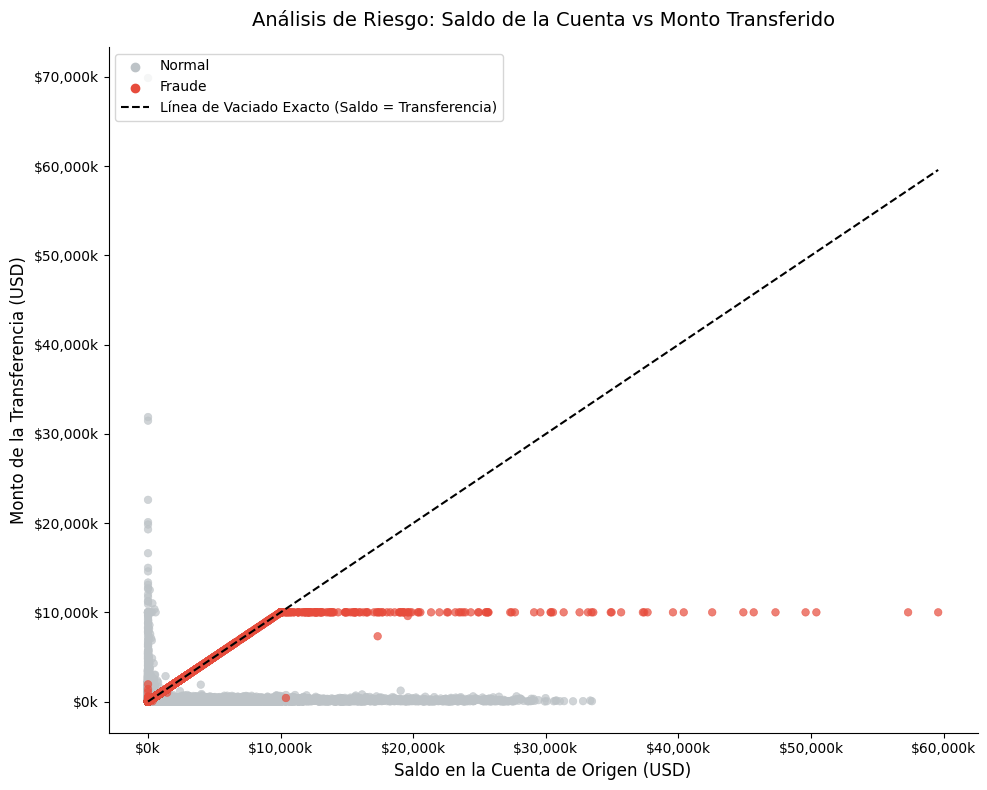

In [41]:
# 1. Preparación de los datos
df_fraudes = data[data['isFraud'] == 1]
df_normales = data[data['isFraud'] == 0].sample(n=50000, random_state=42)

# Unimos ambos para graficar
df_plot = pd.concat([df_normales, df_fraudes])

# CORRECCIÓN: Creamos una nueva columna temporal con etiquetas de texto 
# para que la leyenda de la gráfica y la paleta de colores funcionen perfectamente.
df_plot['Tipo de Transacción'] = df_plot['isFraud'].map({0: 'Normal', 1: 'Fraude'})

# 2. Configurar el lienzo
plt.figure(figsize=(10, 8))

# 3. Crear el gráfico de dispersión
sns.scatterplot(
    data=df_plot,
    x='oldbalanceOrg',  
    y='amount',         
    hue='Tipo de Transacción', # Usamos nuestra nueva columna de texto
    palette={'Normal': '#BDC3C7', 'Fraude': '#E74C3C'}, # Ahora sí coinciden las llaves
    alpha=0.7,          
    s=30,               
    edgecolor=None
)

# 4. Línea de referencia del "Vaciado de Cuenta"
max_val = min(df_plot['oldbalanceOrg'].max(), df_plot['amount'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=1.5, 
         label='Línea de Vaciado Exacto (Saldo = Transferencia)')

# 5. Estilizar la gráfica
plt.title('Análisis de Riesgo: Saldo de la Cuenta vs Monto Transferido', fontsize=14, pad=15)
plt.xlabel('Saldo en la Cuenta de Origen (USD)', fontsize=12)
plt.ylabel('Monto de la Transferencia (USD)', fontsize=12)

# Formato de moneda en los ejes
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x/1e3:,.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x/1e3:,.0f}k'))

# Limpiar bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajustamos la leyenda para que se vea limpia
plt.legend(loc='upper left')
plt.tight_layout()

plt.show()